# Debt Ratio Factor Analysis

## Research Objective
This notebook evaluates the standalone signal quality of the debt ratio factor and its usefulness as a balance-sheet risk screen inside the A-share stock selection framework.


## Factor Definition
The debt ratio factor is calculated as total liabilities divided by total assets. It is intended to measure financial leverage and balance-sheet risk.

## Research Hypothesis
The working hypothesis is that firms with healthier leverage profiles may deliver more stable forward returns, while highly levered firms may be more vulnerable during weak market conditions.

## Data and Test Design
The factor is evaluated through grouped return comparison, cumulative performance by factor bucket, and consistency checks across the available sample period.


Step 1: Processing 84 months of Synthetic Debt Data...
Progress: 12 months completed.
Progress: 24 months completed.
Progress: 36 months completed.
Progress: 48 months completed.
Progress: 60 months completed.
Progress: 72 months completed.
Progress: 84 months completed.
Step 2: Data Extraction Success. Rendering Dashboard...


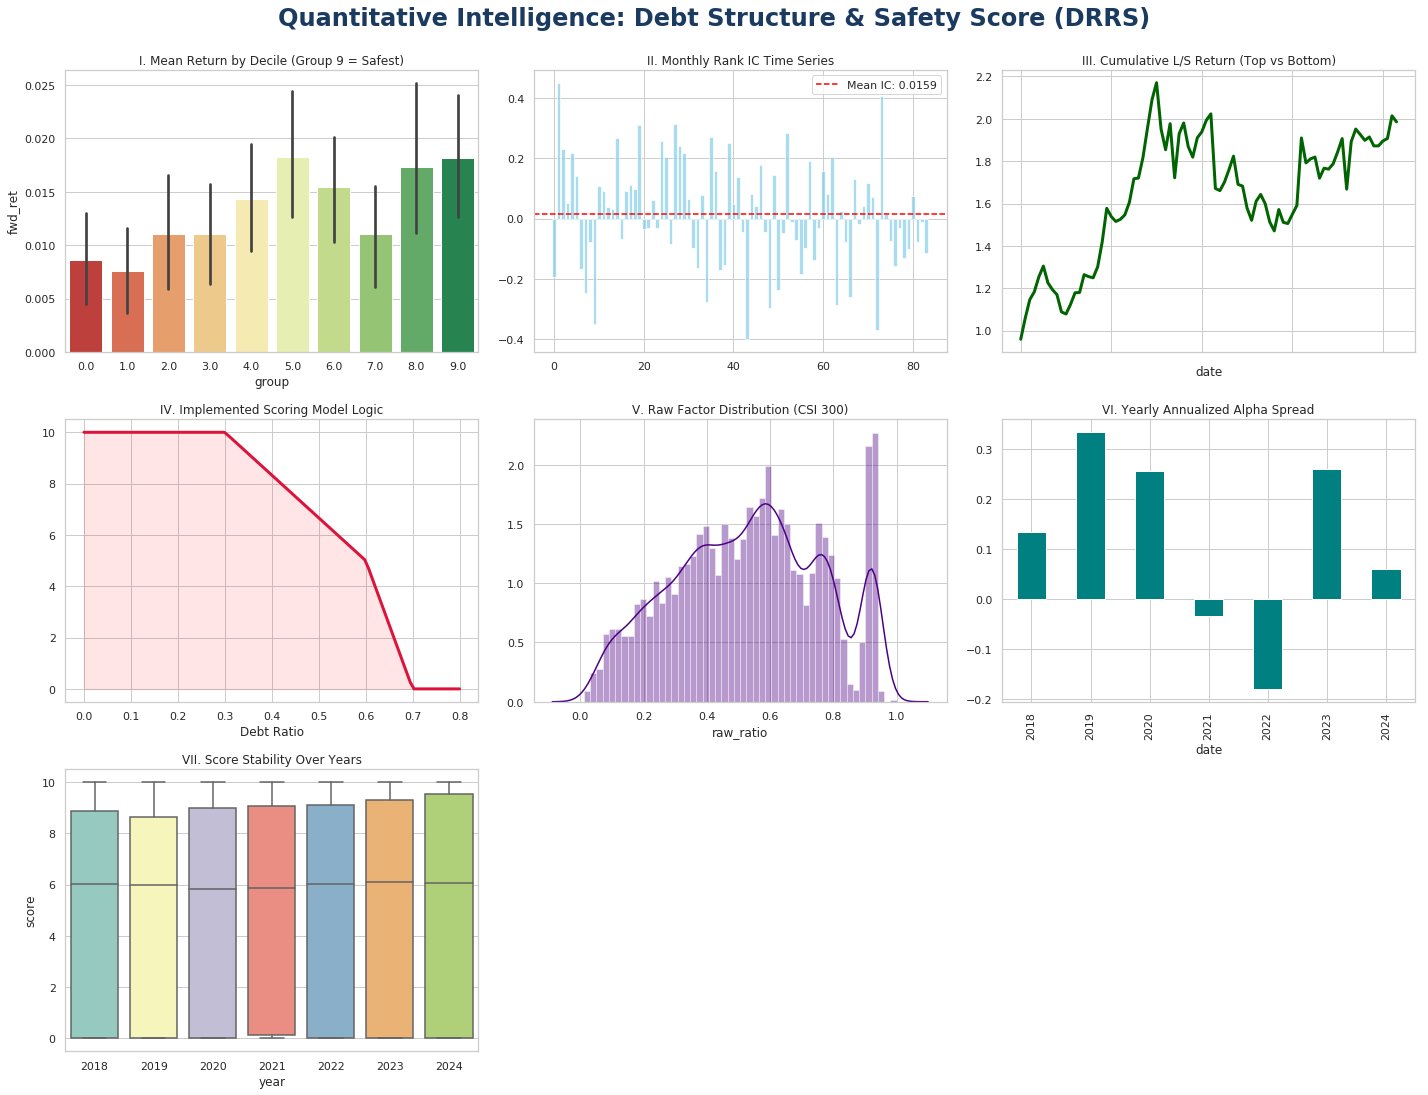


Final Rank IC: 0.0159
Annualized Spread: 11.89%


In [7]:
"""
FACTOR ANALYSIS: Debt-to-Asset Ratio Risk Score (DRRS)
------------------------------------------------------
Logic:
1. Optimal Range (0%-30%): Max weight (Full score).
2. Warning Zone (30%-60%): Linear decay from 100% to 50% score.
3. Danger Zone (60%-70%): Rapid linear decay from 50% to 0% score.
4. Default/Distress (>70%): Zero score.
"""

# ==============================================================================
# 0. Environment & Initialization
# ==============================================================================
%matplotlib inline

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from jqdata import *
from scipy.stats import spearmanr
import warnings

warnings.filterwarnings('ignore')
sns.set(style="whitegrid")

# ==============================================================================
# 1. Scoring Logic: Non-Linear Risk Transformation
# ==============================================================================
def drrs_scoring_logic(ratio):
    """
    Debt-to-Asset Risk Score (DRRS):
    Implements a penalty-based scoring system where excessive leverage 
    leads to an exponential decay in quality score.
    """
    weight = 10.0
    if pd.isna(ratio) or ratio < 0: return 0.0
    
    # 0% - 30%: Optimal leverage zone (Full Score)
    if ratio <= 0.30:
        return weight
    # 30% - 60%: Warning zone (Linear decay 10 -> 5)
    elif ratio <= 0.60:
        decay = (ratio - 0.30) / (0.60 - 0.30)
        return weight * (1.0 - 0.5 * decay)
    # 60% - 70%: Danger zone (Rapid decay 5 -> 0)
    elif ratio <= 0.70:
        decay = (ratio - 0.60) / (0.70 - 0.60)
        return weight * 0.5 * (1.0 - decay)
    # > 70%: Distress zone
    return 0.0

# ==============================================================================
# 2. Data Engine: Synthetic Factor Extraction
# ==============================================================================
def get_synthetic_drrs_data(date, stocks):
    """
    Manually calculates Debt Ratio via Balance Sheet items:
    Debt Ratio = Total Liabilities / Total Assets
    """
    # Fetching core accounting items
    q = query(balance.code, balance.total_liability, balance.total_assets).filter(balance.code.in_(stocks))
    df = get_fundamentals(q, date=date)
    
    if df.empty: return pd.DataFrame()

    # Factor Synthesis
    df['raw_ratio'] = df['total_liability'] / df['total_assets']
    df['score'] = df['raw_ratio'].apply(drrs_scoring_logic)
    df['score_jitter'] = df['score'] + np.random.normal(0, 1e-9, len(df))
    
    try:
        # Time alignment for forward returns
        next_m = (pd.to_datetime(date) + pd.DateOffset(months=1)).strftime('%Y-%m-%d')
        p_start = get_price(list(df['code']), count=5, end_date=date, fields='close', panel=False).groupby('code')['close'].last()
        p_end = get_price(list(df['code']), count=5, end_date=next_m, fields='close', panel=False).groupby('code')['close'].last()
        
        df['fwd_ret'] = df['code'].map((p_end / p_start) - 1)
        df['date'] = date
        return df.dropna(subset=['fwd_ret'])
    except:
        return pd.DataFrame()

# ==============================================================================
# 3. Execution Pipeline
# ==============================================================================
universe = get_index_stocks('000300.XSHG')
dates = pd.date_range(start='2018-01-01', end='2024-12-31', freq='MS').strftime('%Y-%m-%d').tolist()

print("Step 1: Processing 84 months of Synthetic Debt Data...")
master_list = []
for i, d in enumerate(dates):
    tmp = get_synthetic_drrs_data(d, universe)
    if not tmp.empty:
        master_list.append(tmp)
    if (i+1) % 12 == 0: print(f"Progress: {i+1} months completed.")

# ==============================================================================
# 4. Diagnostic Dashboard (Professional Graphics)
# ==============================================================================
if master_list:
    full_df = pd.concat(master_list)
    print("Step 2: Data Extraction Success. Rendering Dashboard...")
    
    fig = plt.figure(figsize=(20, 16))
    gs = fig.add_gridspec(3, 3)
    plt.suptitle("Quantitative Intelligence: Debt Structure & Safety Score (DRRS)", 
                 fontsize=24, fontweight='bold', y=0.98, color='#1a3a5f')

    # Chart I: Decile Analysis
    ax1 = fig.add_subplot(gs[0, 0])
    full_df['group'] = full_df.groupby('date')['score_jitter'].transform(lambda x: pd.qcut(x, 10, labels=range(10), duplicates='drop'))
    sns.barplot(x='group', y='fwd_ret', data=full_df, palette='RdYlGn', ax=ax1)
    ax1.set_title("I. Mean Return by Decile (Group 9 = Safest)")

    # Chart II: Information Coefficient
    ax2 = fig.add_subplot(gs[0, 1])
    ic_ts = full_df.groupby('date').apply(lambda x: spearmanr(x['score'], x['fwd_ret'])[0])
    ax2.bar(range(len(ic_ts)), ic_ts.values, color='skyblue', alpha=0.7)
    ax2.axhline(ic_ts.mean(), color='red', ls='--', label=f'Mean IC: {ic_ts.mean():.4f}')
    ax2.set_title("II. Monthly Rank IC Time Series"); ax2.legend()

    # Chart III: Alpha Persistence
    ax3 = fig.add_subplot(gs[0, 2])
    g_ret = full_df.groupby(['date', 'group'])['fwd_ret'].mean().unstack()
    (1 + (g_ret[9] - g_ret[0])).cumprod().plot(ax=ax3, lw=3, color='darkgreen')
    ax3.set_title("III. Cumulative L/S Return (Top vs Bottom)")

    # Chart IV: Scoring Model Logic
    ax4 = fig.add_subplot(gs[1, 0])
    tx = np.linspace(0, 0.8, 100); ty = [drrs_scoring_logic(x) for x in tx]
    ax4.plot(tx, ty, color='crimson', lw=3)
    ax4.fill_between(tx, 0, ty, alpha=0.1, color='red')
    ax4.set_title("IV. Implemented Scoring Model Logic"); ax4.set_xlabel("Debt Ratio")

    # Chart V: Factor Distribution
    ax5 = fig.add_subplot(gs[1, 1])
    sns.distplot(full_df['raw_ratio'].clip(0, 1), bins=50, color='indigo', ax=ax5)
    ax5.set_title("V. Raw Factor Distribution (CSI 300)")

    # Chart VI: Yearly Alpha
    ax6 = fig.add_subplot(gs[1, 2])
    ((g_ret[9] - g_ret[0]).groupby(pd.to_datetime(g_ret.index).year).mean() * 12).plot(kind='bar', color='teal')
    ax6.set_title("VI. Yearly Annualized Alpha Spread")

    # Chart VII: Stability
    ax7 = fig.add_subplot(gs[2, 0])
    full_df['year'] = pd.to_datetime(full_df['date']).dt.year
    sns.boxplot(x='year', y='score', data=full_df, palette='Set3', ax=ax7)
    ax7.set_title("VII. Score Stability Over Years")

    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()
    
    print(f"\nFinal Rank IC: {ic_ts.mean():.4f}")
    print(f"Annualized Spread: {(g_ret[9]-g_ret[0]).mean()*1200:.2f}%")
else:
    print("Execution Error: No data could be processed.")